In [18]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [19]:
import corner

In [20]:
import scipy.stats

In [21]:
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

In [22]:
import warnings

In [23]:
data = np.load("transient.npy")

<ErrorbarContainer object of 3 artists>

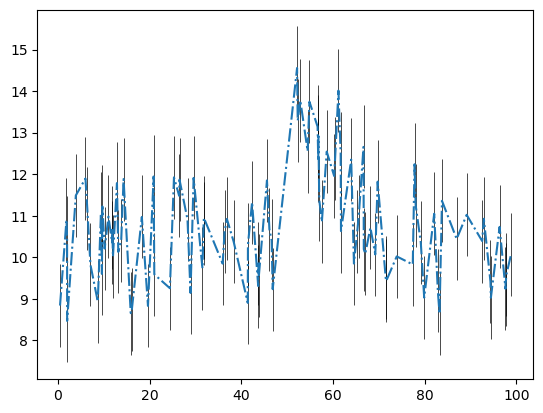

In [24]:
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt="-.", ecolor = "black", elinewidth=0.5)

In [25]:
def model1(params, t):
    A, b, t0, alpha = params
    arr = []
    for i in t:
        if i<t0:    arr.append(b)
        else:       arr.append(b + A*np.exp(-alpha*(i-t0)))
    arr = np.array(arr)

    return arr

def model2(params, t):
    A, b, t0, sigmaw = params
    return b + A*np.exp(-(t-t0)**2 / (2*sigmaw**2))
    

In [26]:
t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)
sigmaWmin,sigmaWmax=np.exp(-2),np.exp(2)

In [27]:
ndim = 4

def loglike(theta, data, model):
    x, y, sigma_y = data.T
    if model == 1:
        y_fit = model1(theta, x)
    elif model == 2:
        y_fit = model2(theta, x)

    # Note I'm not tracking the normalization here! 
    # Ok because here I only care about the ratio between two evidences, not the evidence itself
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model == 1:
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model == 2:
        x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
        #x[3] = scipy.stats.uniform(loc=sigmaWmin,scale=sigmaWmax-sigmaWmin).ppf(u[3])

    return x

In [ ]:
with warnings.catch_warnings():                                 #utile usare with
    # Potentially dangerous, but hey I know what I'm doing. 
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,1],ptform_args=[1],nlive=300)
    sampler.run_nested()
    sresults = sampler.results

#2 minuti e 27 secondi

4606it [02:26, 31.38it/s, +300 | bound: 140 | nc: 1 | ncall: 72902 | eff(%):  6.757 | loglstar:   -inf < -48.762 <    inf | logz: -62.836 +/-  0.209 | dlogz:  0.001 >  0.309]


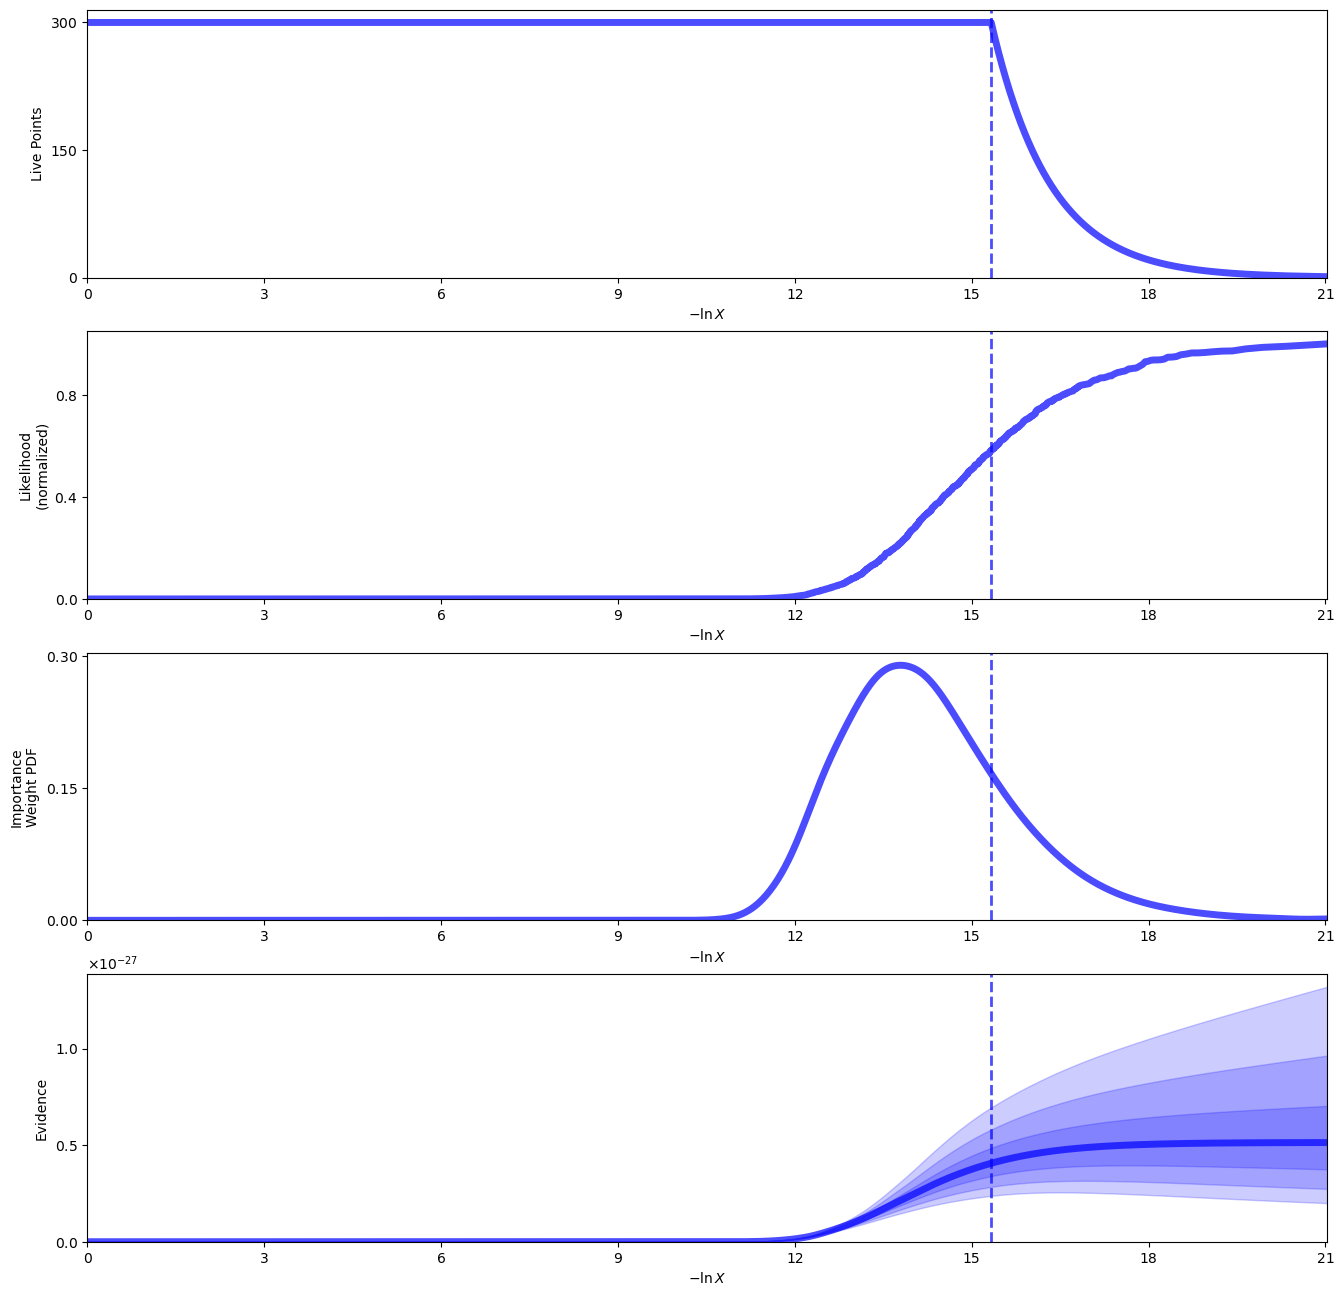

In [29]:
rfig, raxes = dyplot.runplot(sresults)

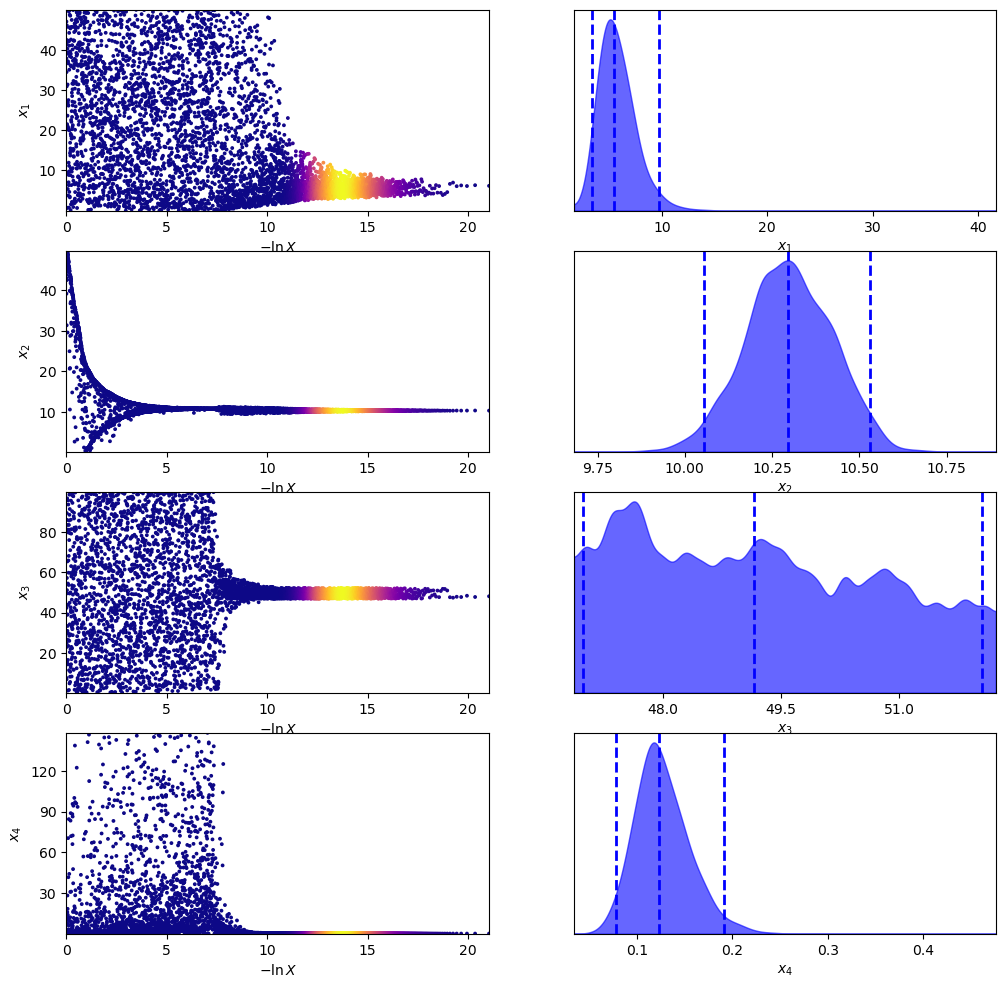

In [30]:
tfig, taxes = dyplot.traceplot(sresults)

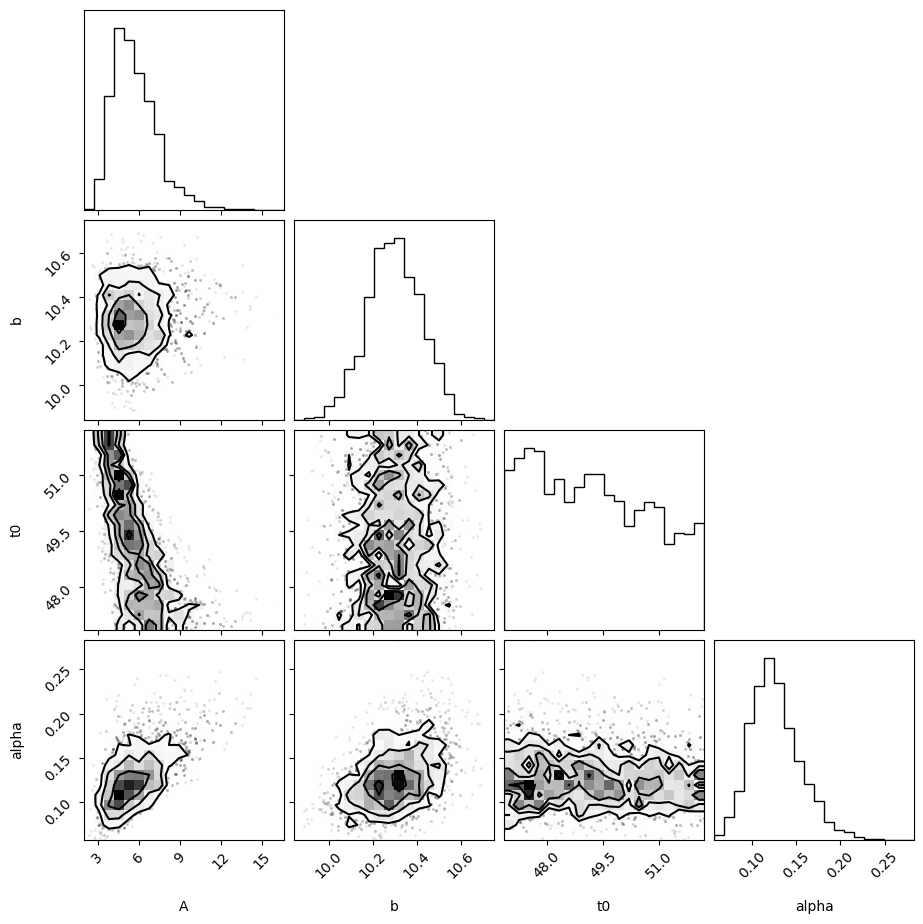

In [31]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [32]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.477212699407944 +3.3371222028189456 -1.8303988137847393
b   10.295427801177249 +0.20181489662445884 -0.20409140693601735
t0   49.158051991049334 +2.6772361490298664 -2.065303197299407
alpha   0.1232449047313472 +0.05451546181424061 -0.03793247869677735


In [33]:
sresults.summary()

Summary
nlive: 300
niter: 4606
ncall: 72602
eff(%):  6.757
logz: -62.836 +/-  0.315


In [ ]:
sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,2],ptform_args=[2],nlive=300, bootstrap=0)
sampler.run_nested()
sresults2 = sampler.results

#3 minuti e 7 secondi
#mi dava un warning
#c:\Users\albad\.conda\envs\astr\lib\site-packages\dynesty\bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
#quindi bootstrap = 0
#1 minuto e 5 secondi ma forse è per della cache

5016it [01:04, 78.07it/s, +300 | bound: 57 | nc: 1 | ncall: 36942 | eff(%): 14.508 | loglstar:   -inf < -52.437 <    inf | logz: -67.906 +/-  0.220 | dlogz:  0.001 >  0.309]


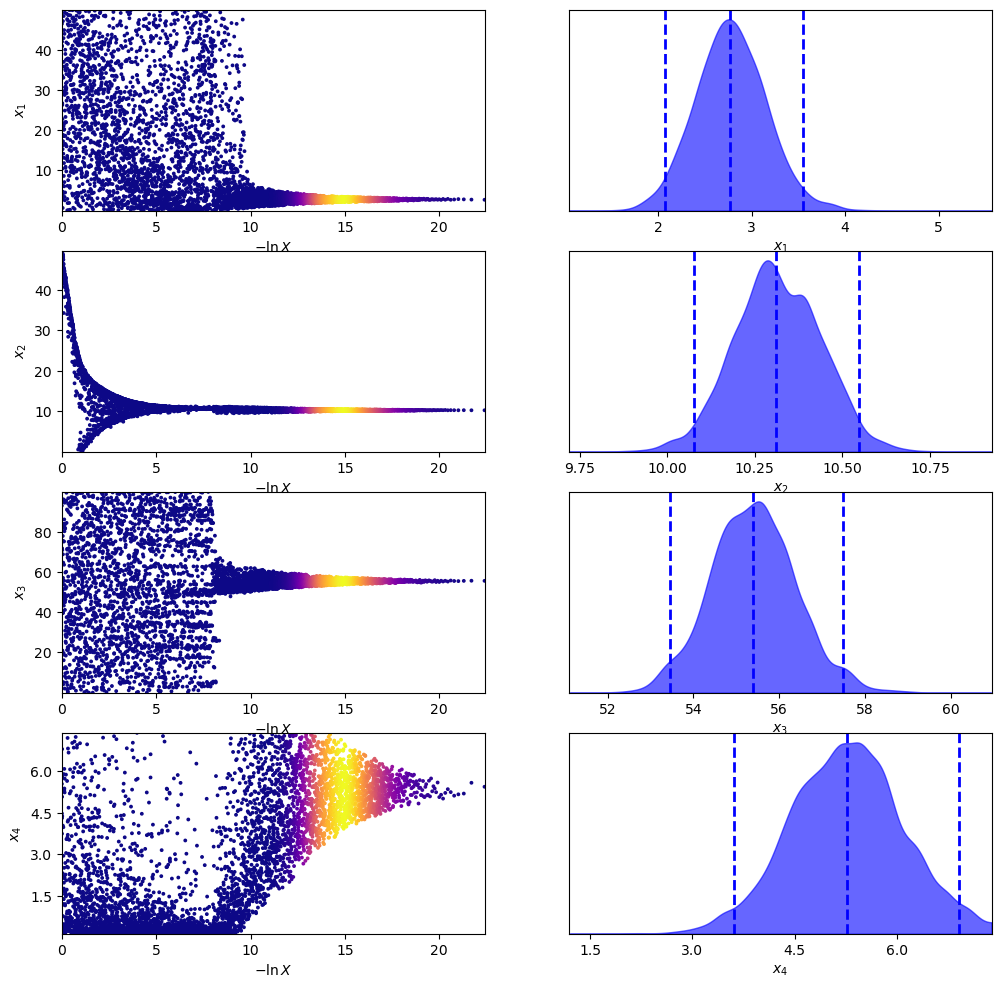

In [37]:
tfig, taxes = dyplot.traceplot(sresults2)

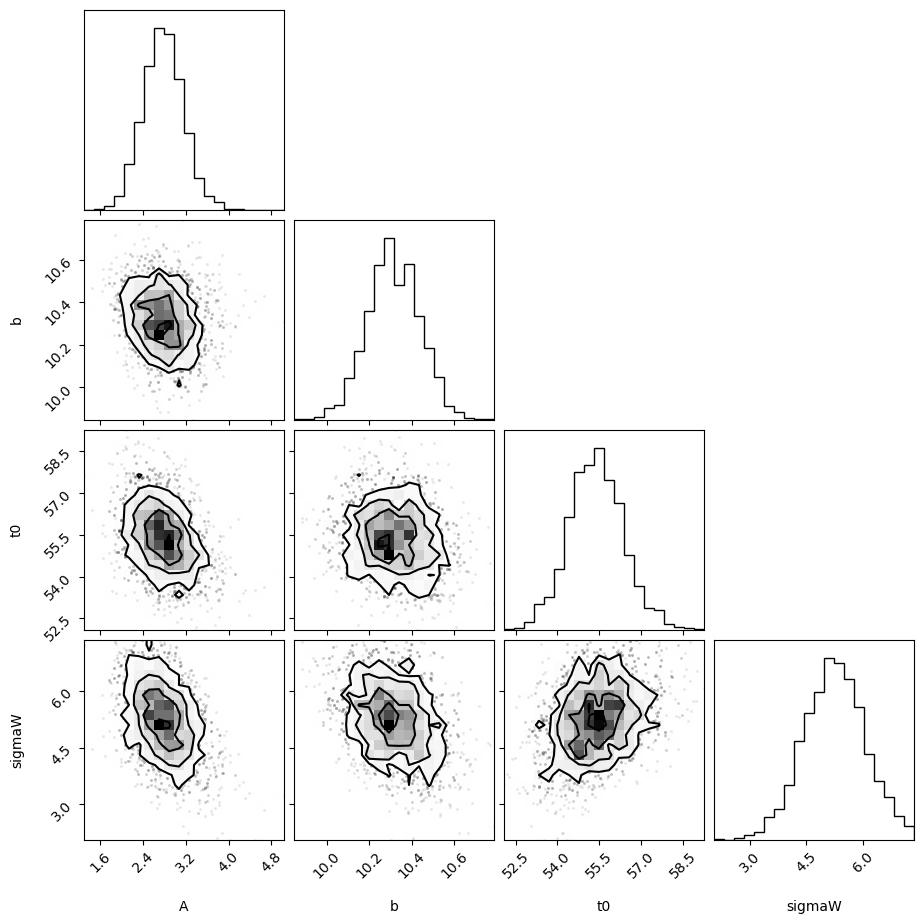

In [38]:
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

labels = ["A","b","t0","sigmaW"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [39]:
sresults2.summary()

Summary
nlive: 300
niter: 5016
ncall: 36642
eff(%): 14.508
logz: -67.906 +/-  0.326


In [40]:
np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])

159.2374934144236

Text(0, 0.5, 'flux')

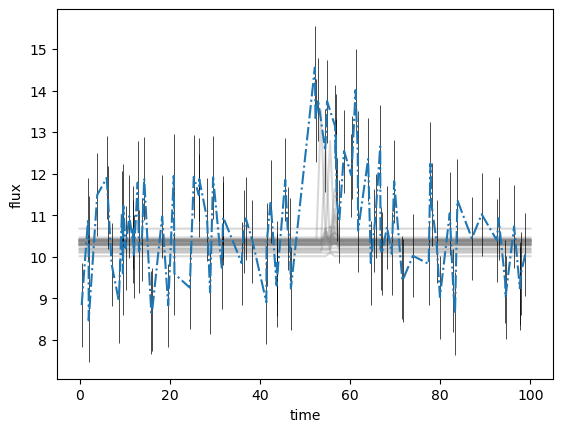

In [42]:
tgrid=np.linspace(0,100,100)

chosen_samples= samples_equal[np.random.choice(len(samples_equal),size=30)]

for chosen_theta in chosen_samples:

    ygrid =  model1(chosen_theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='gray')
    
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt="-.", ecolor = "black", elinewidth=0.5)
plt.xlabel("time")
plt.ylabel("flux")